# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who:** (audience)   
Hospital executives, policymakers, general audience

**What:** (what do you need your audience to know or do?)   
Shared, modifiable risk factors across major preventable noncommunicable diseases, emphasizing population-level prevention strategies and policy-relevant healthcare insights rather than disease-specific clinical diagnosis.   

**How:** (what data is available that will help make my point?)   
Diabetes, obesity, cervical cancer risk factors

# 3. Homework - work with your own data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import OrdinalEncoder

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

[Project List Link](https://docs.google.com/document/d/1BsJIWU4TKUkADvnNEC14b8coQ5VqslJtS7ZBCYJVZAk/edit?usp=sharing)   

**Selected Project:** Preventable Disease Risk Analysis   
This project focuses on identifying shared, modifiable risk factors across major preventable noncommunicable diseases, emphasizing population-level prevention strategies and policy-relevant healthcare insights rather than disease-specific clinical diagnosis.   

**Datasets:**   
[CDC Diabetes Health Indicators](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators)   
[Estimation of Obesity Levels Based on Eating Habits and Physical Condition](https://doi.org/10.24432/C5H31Z)   
[Cervical Cancer Risk Factors](https://doi.org/10.24432/C5Z310)

#### Load Data

###### CDC Diabetes Health Indicators   

The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy.

In [4]:
diabetes_indicators = pd.read_csv('Datasets/diabetes_012_health_indicators_BRFSS2015.csv')

###### Estimation of Obesity Levels Based on Eating Habits and Physical Condition   
This dataset includes data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.   
[More information on variables](https://www.semanticscholar.org/paper/Dataset-for-estimation-of-obesity-levels-based-on-Palechor-Manotas/35b40bacd2ffa9370885b7a3004d88995fd1d011/figure/0)

In [5]:
obesity = pd.read_csv('Datasets/ObesityDataSet_raw_and_data_sinthetic.csv')

###### Cervical Cancer Risk Factors   

The dataset was collected at 'Hospital Universitario de Caracas' in Caracas, Venezuela. The dataset comprises demographic information, habits, and historic medical records of 858 patients. Several patients decided not to answer some of the questions because of privacy concerns (missing values).

In [6]:
cervical_cancer = pd.read_csv('Datasets/risk_factors_cervical_cancer.csv')

#### EDA & Cleaning

###### CDC Diabetes Health Indicators

In [7]:
# Inspect data

In [8]:
diabetes_indicators.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [9]:
diabetes_indicators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [10]:
pd.set_option('display.max_columns', None)

diabetes_indicators.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [11]:
# Change datatypes based on data preview indicating entirely integers

In [12]:
diabetes_indicators = diabetes_indicators.astype('int')

In [13]:
diabetes_indicators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

In [14]:
# Check for duplicates and null values

In [15]:
# Duplicates
diabetes_indicators.duplicated().sum()

np.int64(23899)

In [16]:
# Drop duplicates
diabetes_indicators.drop_duplicates(inplace = True)

In [17]:
# Verify
diabetes_indicators.duplicated().sum()

np.int64(0)

In [18]:
# Null
diabetes_indicators.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [19]:
# Inconsistent data/outliers

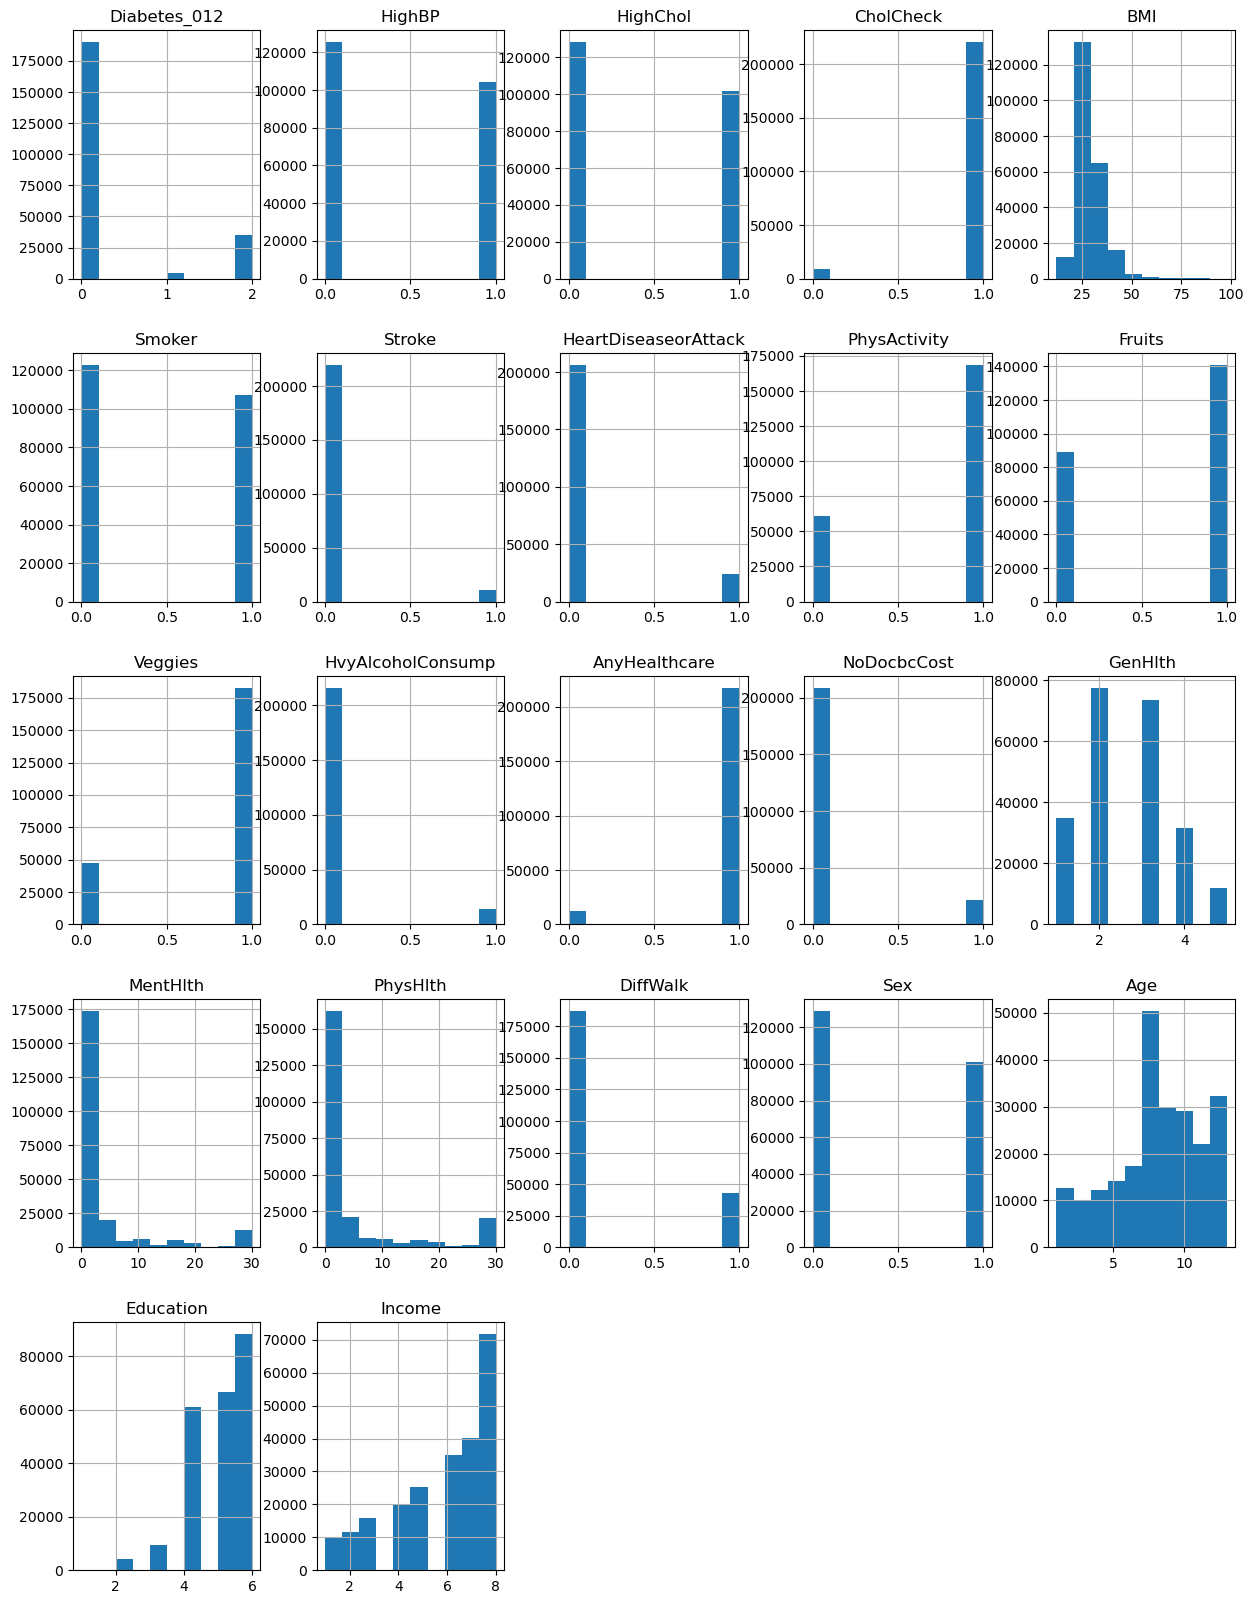

In [20]:
diabetes_indicators.hist(figsize = (15,20))
plt.show()

In [21]:
# Values fall within expected ranges

In [22]:
# Encode categorical variables

In [23]:
# Age: already encoded

[Age Category Reference](https://www.icpsr.umich.edu/web/NAHDAP/studies/34085/datasets/0001/variables/AGEG5YR?archive=NAHDAP)

In [24]:
# Income: already encoded

[Income Level Reference](https://www.icpsr.umich.edu/web/RCMD/studies/34085/datasets/0001/variables/INCOME2?archive=RCMD)

In [25]:
# Education: already encoded

In [26]:
# Class imbalance
float_cols = list(diabetes_indicators.columns[(diabetes_indicators > 1).any()])
print(float_cols)
print()

binary_cols = [col for col in list(diabetes_indicators.columns) if col not in float_cols]
print(binary_cols)
print()

percentages = {
    col: diabetes_indicators[col].value_counts(normalize=True)
    for col in binary_cols
}

print(percentages)

['Diabetes_012', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

{'HighBP': HighBP
0    0.545559
1    0.454441
Name: proportion, dtype: float64, 'HighChol': HighChol
0    0.55824
1    0.44176
Name: proportion, dtype: float64, 'CholCheck': CholCheck
1    0.959535
0    0.040465
Name: proportion, dtype: float64, 'Smoker': Smoker
0    0.534339
1    0.465661
Name: proportion, dtype: float64, 'Stroke': Stroke
0    0.955244
1    0.044756
Name: proportion, dtype: float64, 'HeartDiseaseorAttack': HeartDiseaseorAttack
0    0.896784
1    0.103216
Name: proportion, dtype: float64, 'PhysActivity': PhysActivity
1    0.733355
0    0.266645
Name: proportion, dtype: float64, 'Fruits': Fruits
1    0.612966
0    0.387034
Name: proportion, dtype: float64, 'Veggies': Veggies
1    0.794813
0    0

###### Estimation of Obesity Levels Based on Eating Habits and Physical Condition 

In [27]:
# Inspect data

In [28]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [29]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [30]:
# Rename columns for clarity
obesity.rename(columns = {
    'Age':'Age (yrs)',
    'Height':'Height (m)',
    'Weight':'Weight (kg)',
    'FAVC':'Frequent Caloric Food Intake',
    'FCVC':'Vegetables with Meals',
    'NCP':'# of Main Meals/Day',
    'CAEC':'Snacking',
    'SMOKE':'Smoker',
    'CH2O':'Water/Day',
    'SCC':'Calories Monitored',
    'FAF':'Physical Activity',
    'TUE':'Technology Time',
    'CALC':'Alcohol Frequency',
    'MTRANS':'Transportation Method',
    'NObeyesdad':'Obesity Level'
}, inplace = True)

In [31]:
obesity.describe()

,Age (yrs),Height (m),Weight (kg),Vegetables with Meals,# of Main Meals/Day,Water/Day,Physical Activity,Technology Time
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [32]:
# Check for duplicates and null values

In [33]:
# Duplicates
obesity.duplicated().sum()

np.int64(24)

In [34]:
# Drop duplicates
obesity.drop_duplicates(inplace = True)

In [35]:
# Verify
obesity.duplicated().sum()

np.int64(0)

In [36]:
# Null values
obesity.isna().sum()

Gender                            0
Age (yrs)                         0
Height (m)                        0
Weight (kg)                       0
family_history_with_overweight    0
Frequent Caloric Food Intake      0
Vegetables with Meals             0
# of Main Meals/Day               0
Snacking                          0
Smoker                            0
Water/Day                         0
Calories Monitored                0
Physical Activity                 0
Technology Time                   0
Alcohol Frequency                 0
Transportation Method             0
Obesity Level                     0
dtype: int64

In [37]:
# Inconsistent data/outliers

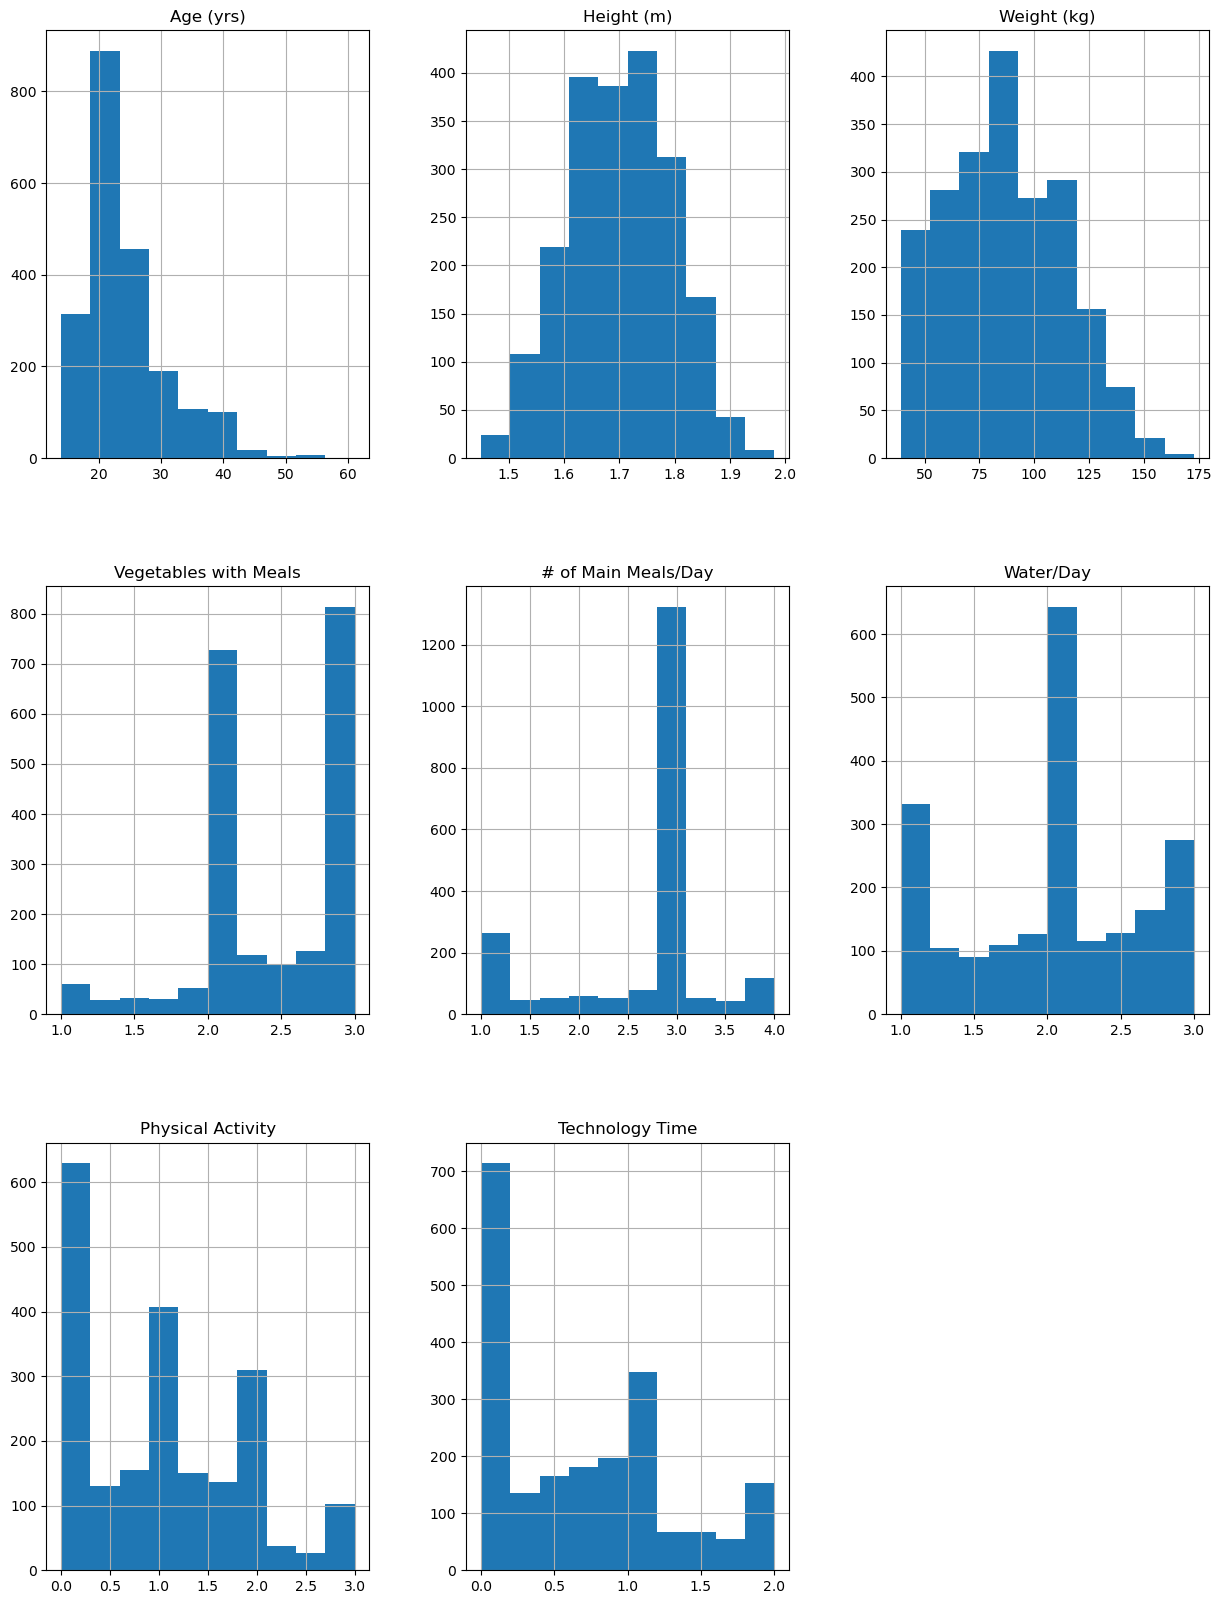

In [38]:
obesity.hist(figsize = (15, 20))
plt.show()

In [39]:
# Encode categorical variables

In [40]:
obesity.head()

,Gender,Age (yrs),Height (m),Weight (kg),family_history_with_overweight,Frequent Caloric Food Intake,Vegetables with Meals,# of Main Meals/Day,Snacking,Smoker,Water/Day,Calories Monitored,Physical Activity,Technology Time,Alcohol Frequency,Transportation Method,Obesity Level
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [41]:
# One-Hot Encode Gender, family_history_with_overweight, Frequent Caloric Food Intake, Smoker, Calories Monitored, Transportation Method

obesity = pd.get_dummies(obesity, 
                         columns = ['Gender', 'family_history_with_overweight', 'Frequent Caloric Food Intake', 'Smoker', 'Calories Monitored', 'Transportation Method'], 
                         drop_first = True)

In [42]:
# Snacking

In [43]:
obesity['Snacking'].unique()

array(['Sometimes', 'Frequently', 'Always', 'no'], dtype=object)

In [44]:
encoder = OrdinalEncoder(categories = [['no', 'Sometimes', 'Frequently', 'Always']])

encoded_col = encoder.fit_transform(obesity[['Snacking']])

obesity['Snacking (Encoded)'] = encoded_col.astype(int)

obesity = obesity.drop('Snacking', axis = 1)

In [45]:
# Alcohol Frequency

In [46]:
obesity['Alcohol Frequency'].unique()

array(['no', 'Sometimes', 'Frequently', 'Always'], dtype=object)

In [47]:
# same encoder as before
encoded_col = encoder.fit_transform(obesity[['Alcohol Frequency']])

obesity['Alcohol Frequency (Encoded)'] = encoded_col.astype(int)

obesity = obesity.drop('Alcohol Frequency', axis = 1)

In [48]:
# Obesity Level: leaving as categorical for now (documentation says most modern libraries handle categorical target variables)

In [49]:
obesity['Obesity Level'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [55]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 20 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age (yrs)                                    2087 non-null   float64
 1   Height (m)                                   2087 non-null   float64
 2   Weight (kg)                                  2087 non-null   float64
 3   Vegetables with Meals                        2087 non-null   float64
 4   # of Main Meals/Day                          2087 non-null   float64
 5   Water/Day                                    2087 non-null   float64
 6   Physical Activity                            2087 non-null   float64
 7   Technology Time                              2087 non-null   float64
 8   Obesity Level                                2087 non-null   object 
 9   Gender_Male                                  2087 non-null   bool   
 10  famil

In [57]:
# Convert bool to numeric

bools = obesity.select_dtypes(include = 'bool').columns

obesity[bools] = obesity[bools].astype('Int64')

In [59]:
# Class imbalance
float_cols = list(obesity.select_dtypes(include = 'number').columns[(obesity.select_dtypes(include = 'number') > 1).any()])
print(float_cols)
print()

binary_cols = [col for col in list(obesity.select_dtypes(include = 'number').columns) if col not in float_cols]
print(binary_cols)
print()

percentages = {
    col: obesity[col].value_counts(normalize=True)
    for col in binary_cols
}

print(percentages)

['Age (yrs)', 'Height (m)', 'Weight (kg)', 'Vegetables with Meals', '# of Main Meals/Day', 'Water/Day', 'Physical Activity', 'Technology Time', 'Snacking (Encoded)', 'Alcohol Frequency (Encoded)']

['Gender_Male', 'family_history_with_overweight_yes', 'Frequent Caloric Food Intake_yes', 'Smoker_yes', 'Calories Monitored_yes', 'Transportation Method_Bike', 'Transportation Method_Motorbike', 'Transportation Method_Public_Transportation', 'Transportation Method_Walking']

{'Gender_Male': Gender_Male
1    0.504073
0    0.495927
Name: proportion, dtype: Float64, 'family_history_with_overweight_yes': family_history_with_overweight_yes
1    0.825108
0    0.174892
Name: proportion, dtype: Float64, 'Frequent Caloric Food Intake_yes': Frequent Caloric Food Intake_yes
1    0.883565
0    0.116435
Name: proportion, dtype: Float64, 'Smoker_yes': Smoker_yes
0    0.978917
1    0.021083
Name: proportion, dtype: Float64, 'Calories Monitored_yes': Calories Monitored_yes
0    0.954001
1    0.045999
Name: 

###### Cervical Cancer Risk Factors 

In [ ]:
# Inspect data

In [60]:
cervical_cancer.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0


In [ ]:
# Why are there question marks? May need to replace with null values

In [61]:
cervical_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [ ]:
# Dtypes are off, may need to inspect unique values of certain columns

In [62]:
for col in cervical_cancer.columns:
    print(f"Column: {col} Unique Values: {np.sort(cervical_cancer[col].unique())}\n")

Column: Age Unique Values: [13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36
 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 59 70 79 84]

Column: Number of sexual partners Unique Values: ['1.0' '10.0' '15.0' '2.0' '28.0' '3.0' '4.0' '5.0' '6.0' '7.0' '8.0'
 '9.0' '?']

Column: First sexual intercourse Unique Values: ['10.0' '11.0' '12.0' '13.0' '14.0' '15.0' '16.0' '17.0' '18.0' '19.0'
 '20.0' '21.0' '22.0' '23.0' '24.0' '25.0' '26.0' '27.0' '28.0' '29.0'
 '32.0' '?']

Column: Num of pregnancies Unique Values: ['0.0' '1.0' '10.0' '11.0' '2.0' '3.0' '4.0' '5.0' '6.0' '7.0' '8.0' '?']

Column: Smokes Unique Values: ['0.0' '1.0' '?']

Column: Smokes (years) Unique Values: ['0.0' '0.16' '0.5' '1.0' '1.266972909' '10.0' '11.0' '12.0' '13.0' '14.0'
 '15.0' '16.0' '18.0' '19.0' '2.0' '20.0' '21.0' '22.0' '24.0' '28.0'
 '3.0' '32.0' '34.0' '37.0' '4.0' '5.0' '6.0' '7.0' '8.0' '9.0' '?']

Column: Smokes (packs/year) Unique Values: ['0.0' '0.001' '0.003' '0.025' '0.04' '

In [ ]:
# Convert dtypes

In [63]:
# Columns to convert from string to float
cols_to_convert = list(cervical_cancer.select_dtypes(exclude = 'int64').columns)
print(cols_to_convert)

['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']


In [64]:
# Convert
cervical_cancer[cols_to_convert] = cervical_cancer[cols_to_convert].apply(pd.to_numeric, errors = 'coerce')

In [ ]:
# Set binary columns to binary

In [65]:
# List columns to convert to binary
float_cols = list(cervical_cancer.columns[(cervical_cancer > 1).any()])
print(float_cols)
print()
binary_cols = [col for col in list(cervical_cancer.columns) if col not in float_cols]
print(binary_cols)

['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']

['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']


In [66]:
# Convert
cervical_cancer[binary_cols] = cervical_cancer[binary_cols].astype('Int64')

In [67]:
# Verify
cervical_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    Int64  
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    Int64  
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    Int64  
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [68]:
# Describe
cervical_cancer.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,832.000000,851.000000,802.000000,845.0,845.000000,845.000000,750.0,750.000000,741.0,741.000000,753.0,753.000000,753.0,753.0,753.0,753.0,753.0,753.0,753.0,753.0,753.0,753.0,753.0,753.0,858.000000,71.000000,71.000000,858.0,858.0,858.0,858.0,858.0,858.0,858.0,858.0
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.453144,0.641333,2.256419,0.112011,0.514804,0.104914,0.176627,0.058433,0.0,0.005312,0.057105,0.023904,0.001328,0.001328,0.001328,0.0,0.023904,0.001328,0.002656,0.087413,6.140845,5.816901,0.020979,0.01049,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.667760,2.803355,1.447414,0.352876,4.089017,2.226610,0.479929,3.764254,0.315593,1.943089,0.306646,0.561993,0.234716,0.0,0.072739,0.232197,0.152853,0.036442,0.036442,0.036442,0.0,0.152853,0.036442,0.051503,0.302545,5.895024,5.755271,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,20.000000,2.000000,15.000000,1.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.000000,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,25.000000,2.000000,17.000000,2.000000,0.0,0.000000,0.000000,1.0,0.500000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,4.000000,3.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,32.000000,3.000000,18.000000,3.000000,0.0,0.000000,0.000000,1.0,3.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,8.000000,7.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,84.000000,28.000000,32.000000,11.000000,1.0,37.000000,37.000000,1.0,30.000000,1.0,19.000000,1.0,4.000000,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,3.000000,22.000000,22.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# Check for duplicates and null values

In [69]:
# Duplicates

cervical_cancer.duplicated().sum()

np.int64(23)

In [70]:
# Drop duplicates
cervical_cancer.drop_duplicates(inplace = True)

In [71]:
# Verify
cervical_cancer.duplicated().sum()

np.int64(0)

In [ ]:
# Inconsistent data/outliers

It's either lucky or the data is incorrect that no patients have ever gotten HIV. Not enough context to know. There is also no occurrence of cervical condylomatosis.

In [ ]:
# Encode categorical variables

N/A

In [72]:
# Class imbalance

percentages = {
    col: cervical_cancer[col].value_counts(normalize=True)
    for col in binary_cols
}

print(percentages)

{'Smokes': Smokes
0    0.850365
1    0.149635
Name: proportion, dtype: Float64, 'Hormonal Contraceptives': Hormonal Contraceptives
1    0.651639
0    0.348361
Name: proportion, dtype: Float64, 'IUD': IUD
0    0.885201
1    0.114799
Name: proportion, dtype: Float64, 'STDs': STDs
0    0.892517
1    0.107483
Name: proportion, dtype: Float64, 'STDs:condylomatosis': STDs:condylomatosis
0    0.940136
1    0.059864
Name: proportion, dtype: Float64, 'STDs:cervical condylomatosis': STDs:cervical condylomatosis
0    1.0
Name: proportion, dtype: Float64, 'STDs:vaginal condylomatosis': STDs:vaginal condylomatosis
0    0.994558
1    0.005442
Name: proportion, dtype: Float64, 'STDs:vulvo-perineal condylomatosis': STDs:vulvo-perineal condylomatosis
0    0.941497
1    0.058503
Name: proportion, dtype: Float64, 'STDs:syphilis': STDs:syphilis
0    0.97551
1    0.02449
Name: proportion, dtype: Float64, 'STDs:pelvic inflammatory disease': STDs:pelvic inflammatory disease
0    0.998639
1    0.001361
Name: 

### Save modified dataframes for future notebook use

In [73]:
diabetes_indicators.to_csv('Modified_Datasets/diabetes_indicators.csv', index = False)

In [74]:
obesity.to_csv('Modified_Datasets/obesity.csv', index = False)

In [75]:
cervical_cancer.to_csv('Modified_Datasets/cervical_cancer.csv', index = False)

### Conclusions:

- **Are the data usable?** Yes

- **Do you need to modify or correct the data in some way?** Yes, needed to one hot encode categorical variables, change datatypes, etc.

- **Is there any class imbalance?**  (Categories that have many more items than other categories). Yes, class imbalance exists for many categories. To be dealt with in later steps of the process.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

[]

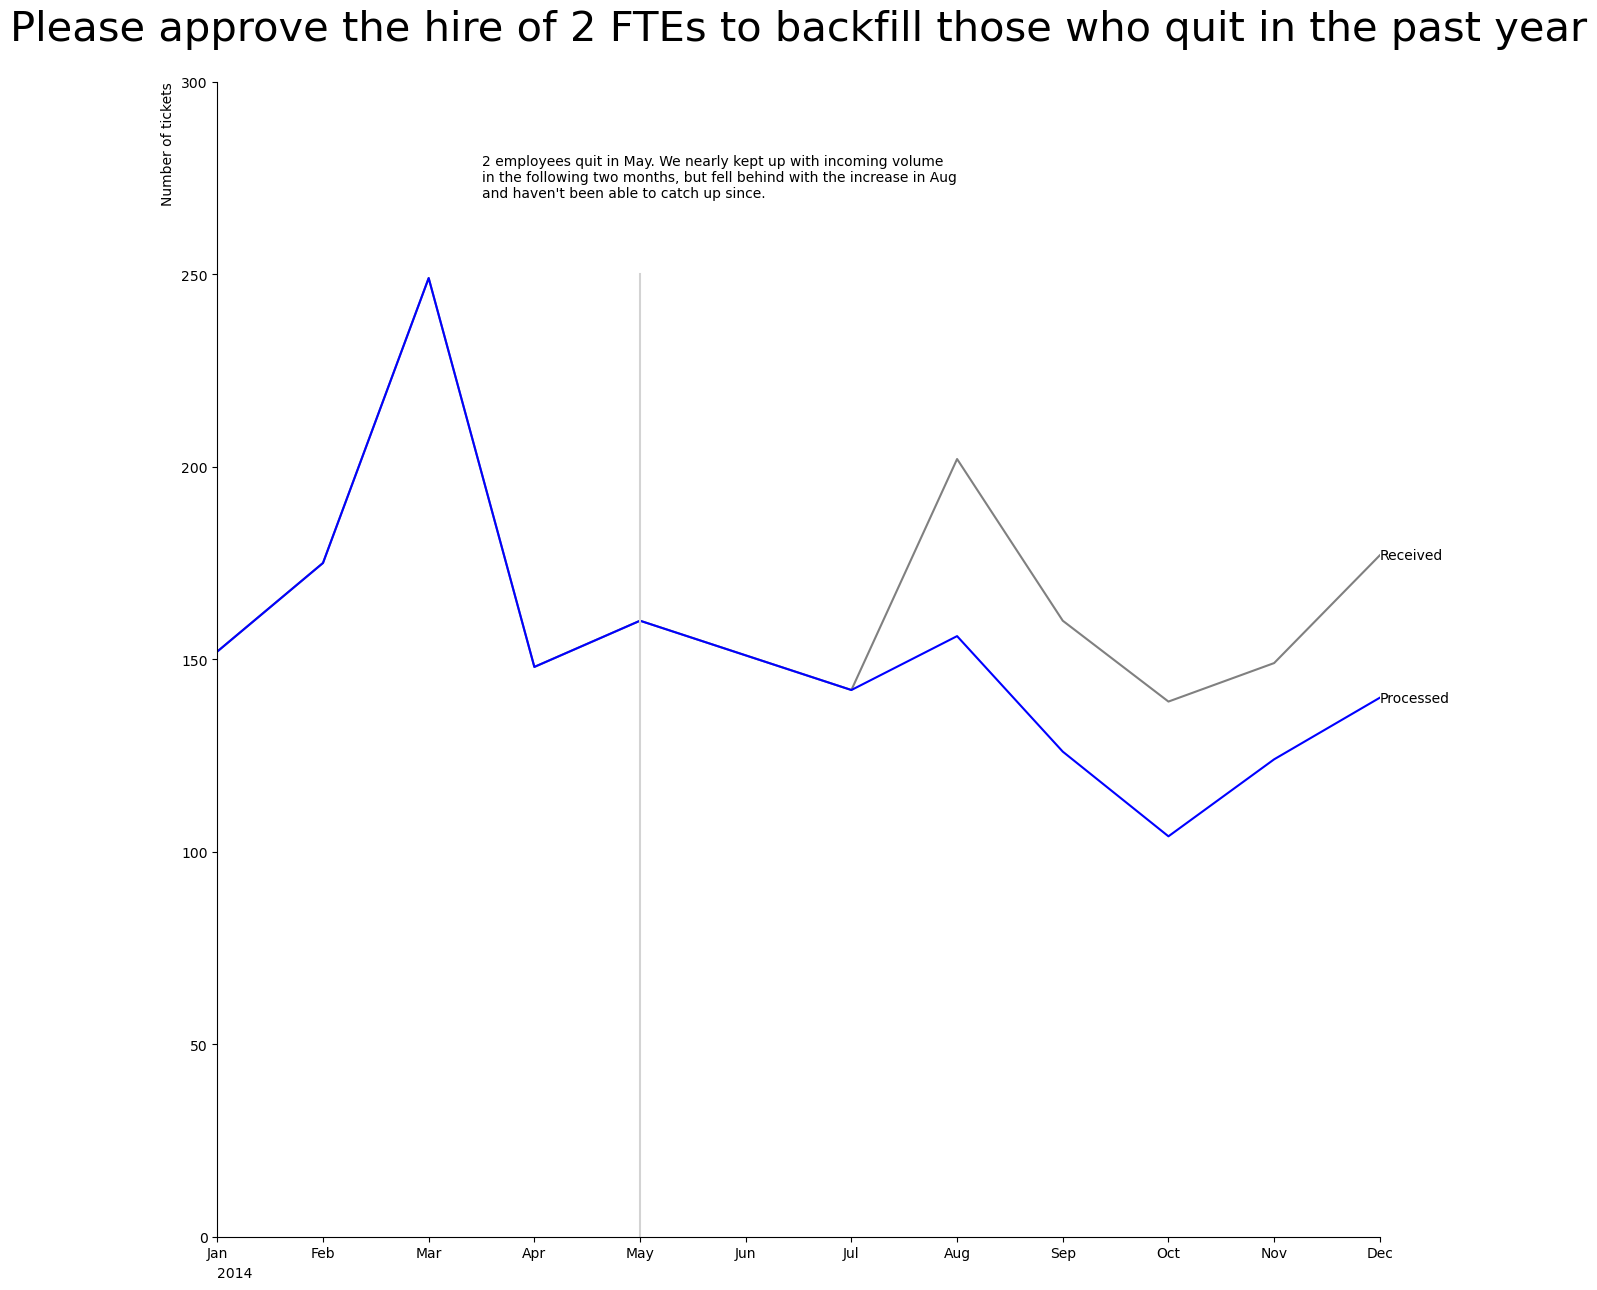

In [76]:
# Note: the graph may look funky but that's how the figure was displayed

x = np.array([1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12])
y1 = np.array([152, 175, 249, 148, 160, 142, 156, 126, 104, 124, 140])
y2 = np.array([152, 175, 249, 148, 160, 142, 202, 160, 139, 149, 177])
y3 = np.array([0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250])

plt.figure(figsize = (15,15))
plt.plot(x, y2, label = 'Received', c = 'gray')
plt.plot(x, y1, label = 'Processed', c = 'b')
plt.plot(np.full(y3.shape, 5), y3, c = 'lightgray')
plt.xlabel('2014', loc = 'left')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Number of tickets', loc = 'top')
plt.ylim(0, 300)
plt.xlim(1,12)
plt.text(3.5, 270, f"2 employees quit in May. We nearly kept up with incoming volume \nin the following two months, but fell behind with the increase in Aug \nand haven't been able to catch up since.")
plt.text(x[-1], y2[-1], 'Received', va = 'center', ha = 'left')
plt.text(x[-1], y1[-1], 'Processed', va = 'center', ha = 'left')
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.title('Please approve the hire of 2 FTEs to backfill those who quit in the past year', fontsize = 30, pad = 30)
plt.plot()